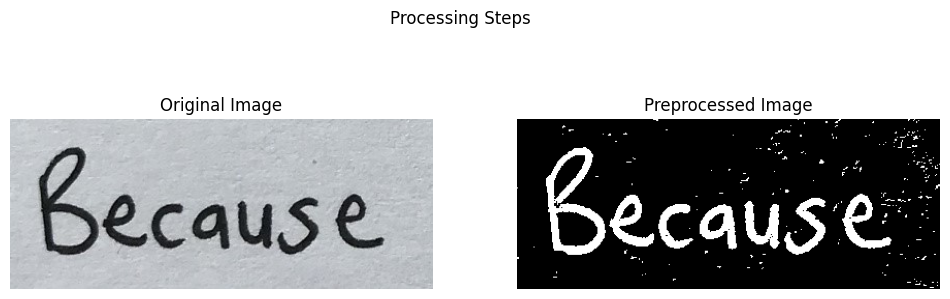

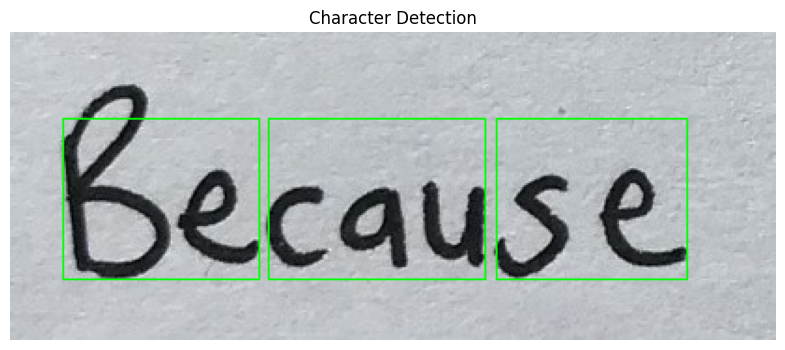

Recognized Text: because


In [16]:
import cv2
import numpy as np
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt

def visualize_steps(original, preprocessed, title="Processing Steps"):
    plt.figure(figsize=(12, 4))
    plt.subplot(121)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(122)
    plt.imshow(preprocessed, cmap='gray')
    plt.title("Preprocessed Image")
    plt.axis('off')
    
    plt.suptitle(title)
    plt.show()

def preprocess_image(image_path):
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise Exception(f"Could not read image at {image_path}")
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Denoise
    denoised = cv2.fastNlMeansDenoising(gray)
    
    # Binarization with adaptive threshold
    binary = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                 cv2.THRESH_BINARY_INV, 21, 10)
    
    return binary, img

def segment_lines(binary_img):
    # Get horizontal projection profile
    h_proj = np.sum(binary_img, axis=1)
    
    # Find line boundaries
    line_boundaries = []
    start = None
    threshold = np.max(h_proj) * 0.1  # Adjust threshold as needed
    
    for i, count in enumerate(h_proj):
        if count > threshold and start is None:
            start = i
        elif count <= threshold and start is not None:
            line_boundaries.append((start, i))
            start = None
    
    if start is not None:
        line_boundaries.append((start, len(h_proj)))
    
    return line_boundaries

def segment_characters(line_img):
    # Get vertical projection profile
    v_proj = np.sum(line_img, axis=0)
    
    # Calculate dynamic threshold based on average projection value
    avg_projection = np.mean(v_proj[v_proj > 0])
    threshold = avg_projection * 0.3  # Lowered threshold for better connection detection
    
    # Find character boundaries
    char_boundaries = []
    start = None
    min_width = 5  # Minimum character width
    max_width = int(line_img.shape[0] * 1.5)  # Maximum character width based on height
    
    for i, count in enumerate(v_proj):
        if count > threshold and start is None:
            start = i
        elif (count <= threshold or i == len(v_proj)-1) and start is not None:
            width = i - start
            # Check if the width is reasonable for a character
            if min_width < width < max_width:
                # Check if this might be a capital letter
                if width > line_img.shape[0] * 0.8:  # If width is close to height, likely a capital
                    char_boundaries.append((start, i))
                else:
                    char_boundaries.append((start, i))
            start = None
    
    # Merge boundaries that are too close (likely parts of the same character)
    merged_boundaries = []
    if char_boundaries:
        current_start, current_end = char_boundaries[0]
        
        for i in range(1, len(char_boundaries)):
            next_start, next_end = char_boundaries[i]
            gap = next_start - current_end
            
            # If the gap is small or the combined width is reasonable
            if gap < min_width or (next_end - current_start) < max_width:
                current_end = next_end  # Merge the boundaries
            else:
                merged_boundaries.append((current_start, current_end))
                current_start, current_end = next_start, next_end
        
        merged_boundaries.append((current_start, current_end))
    
    return merged_boundaries

def recognize_text(binary_img, original_img):
    debug_img = original_img.copy()
    recognized_text = ""
    
    # Segment into lines
    line_boundaries = segment_lines(binary_img)
    
    for line_start, line_end in line_boundaries:
        line_img = binary_img[line_start:line_end, :]
        
        # Segment line into characters
        char_boundaries = segment_characters(line_img)
        
        for char_start, char_end in char_boundaries:
            # Extract character
            char_img = line_img[:, char_start:char_end]
            
            # Add padding (increased for better recognition)
            pad_size = 15
            char_img = cv2.copyMakeBorder(char_img, pad_size, pad_size, pad_size, pad_size,
                                        cv2.BORDER_CONSTANT, value=0)
            
            # Resize while maintaining aspect ratio
            target_height = 28
            aspect_ratio = char_img.shape[1] / char_img.shape[0]
            target_width = int(target_height * aspect_ratio)
            target_width = max(min(target_width, 28), 20)  # Keep width between 20 and 28
            
            char_img = cv2.resize(char_img, (target_width, target_height), 
                                interpolation=cv2.INTER_AREA)
            
            # Add final padding to make it square if needed
            if target_width < 28:
                pad_width = (28 - target_width) // 2
                char_img = cv2.copyMakeBorder(char_img, 0, 0, pad_width, pad_width,
                                            cv2.BORDER_CONSTANT, value=0)
            
            # Convert to PIL Image
            pil_img = Image.fromarray(char_img)
            
            # Recognize character with adjusted configuration
            char = pytesseract.image_to_string(
                pil_img,
                config='--psm 10 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
            )
            
            if char.strip():
                recognized_text += char.strip()
            
            # Draw bounding box
            cv2.rectangle(debug_img, 
                         (char_start, line_start), 
                         (char_end, line_end),
                         (0, 255, 0), 1)
    
    # Show debug image
    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.title("Character Detection")
    plt.axis('off')
    plt.show()
    
    return recognized_text

def handwriting_recognition(image_path):
    # Preprocess image
    binary_img, original_img = preprocess_image(image_path)
    
    # Visualize preprocessing
    visualize_steps(original_img, binary_img)
    
    # Recognize text
    text = recognize_text(binary_img, original_img)
    
    return text

# Run the recognition
if __name__ == "__main__":
    image_path = "./Images/because_handwriting.jpeg"
    try:
        result = handwriting_recognition(image_path)
        print("Recognized Text:", result)
    except Exception as e:
        print(f"An error occurred: {str(e)}")